In [ ]:
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras.layers import (Input,Dense,Activation,BatchNormalization,Flatten,Conv2D,MaxPooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
K.set_image_data_format('channels_last')
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

In [3]:
path = '/kaggle/input/datasets/mdjahed0/imagenet-small-dataset-for-alexnet/training_set-20260824T150746Z-1-001/training_set'
train_datagen =ImageDataGenerator(rescale=1./255) #normalization(0-255)
train = train_datagen.flow_from_directory(path, target_size =(277,277), class_mode='categorical')

Found 4000 images belonging to 10 classes.


In [4]:
print("Batch size for input image:", train[0][0].shape)
print("Batch size for Output image:", train[0][1].shape)
print("Image size for first image:", train[0][0][0].shape)
print("output size of first image:", train[0][1][0].shape)


Batch size for input image: (32, 277, 277, 3)
Batch size for Output image: (32, 10)
Image size for first image: (277, 277, 3)
output size of first image: (10,)


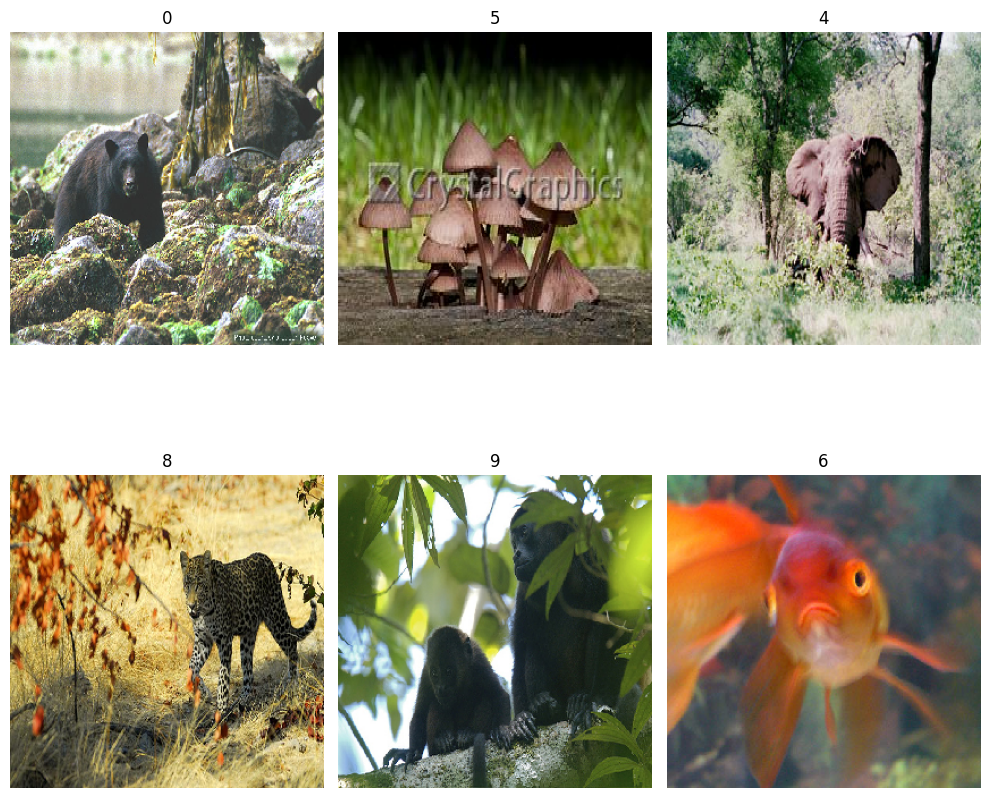

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# images and labels taken from your structure
images = train[0][0]
labels = train[0][1]

def label_to_text(label):
    if isinstance(label, str):
        return label
    arr = np.asarray(label)
    if arr.ndim == 0 or arr.size == 1:
        return str(arr.item())
    return str(int(np.argmax(arr)))

indices = [12, 10, 5, 20, 25, 3]

fig, axs = plt.subplots(2, 3, figsize=(10, 10))

for ax, idx in zip(axs.flat, indices):
    img = images[idx]
    title = label_to_text(labels[idx])

    img_arr = np.asarray(img)
    if img_arr.ndim == 2:
        ax.imshow(img_arr, cmap='gray')
    elif img_arr.ndim == 3 and img_arr.shape[2] == 1:
        ax.imshow(img_arr.squeeze(), cmap='gray')
    else:
        ax.imshow(img_arr)

    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [6]:
def AlexNet(input_shape):
    X_input=Input(input_shape)
    
    # 1st conv block
    
    X = Conv2D(96,(11,11),strides = 4,name="conv0")(X_input)
    X = BatchNormalization(axis = 3 , name = "bn0")(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3,3),strides=2, name='max0')(X)

    # 2nd conv block
    
    X = Conv2D(256,(5,5),padding = 'same' , name = 'conv1')(X)
    X = BatchNormalization(axis = 3 ,name='bn1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3,3),strides = 2,name = 'max1')(X)

    # 3rd conv block
    
    X = Conv2D(384, (3,3) , padding = 'same' , name='conv2')(X)
    X = BatchNormalization(axis = 3, name = 'bn2')(X)
    X = Activation('relu')(X)

    # 4th conv block

    X = Conv2D(384, (3,3) , padding = 'same' , name='conv3')(X)
    X = BatchNormalization(axis = 3, name = 'bn3')(X)
    X = Activation('relu')(X)

    # 5th conv block

    X = Conv2D(256, (3,3) , padding = 'same' , name='conv4')(X)
    X = BatchNormalization(axis = 3, name = 'bn4')(X)
    X = Activation('relu')(X)

    # 6th Pooling block

    X = MaxPooling2D((3,3),strides = 2,name = 'max2')(X) 

    # Flatten

    X = Flatten()(X)

    # 7th FC layer blocks

    X = Dense(4096, activation = 'relu', name = "fc0")(X)
    X = Dense(4096, activation = 'relu', name = "fc1")(X)

    X = Dense(10, activation='softmax', name='fc2')(X) #### probability

    model=Model(inputs=X_input, outputs=X, name='AlexNet')

    return model 

In [7]:
alex=AlexNet(train[0][0].shape[1:])

I0000 00:00:1787680996.822077    1385 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787680996.824448    1385 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
alex.summary()

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 277, 277, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 67, 67, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 67, 67, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 67, 67, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max0 (MaxPooling2D)             │ (None, 33, 33, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 33, 33, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 33, 33, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 33, 33, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max1 (MaxPooling2D)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max2 (MaxPooling2D)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc0 (Dense)                     │ (None, 4096)           │    51,384,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,959,306 (274.50 MB)

 Trainable params: 71,956,554 (274.49 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [10]:
alex.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
alex.fit(train, epochs=98) # training on the train dataset

# Prediction

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import matplotlib.pyplot as pl

In [ ]:
img_path = "/kaggle/input/datasets/mdjahed0/imagenet-small-dataset-for-alexnet/test_set-20260824T150536Z-1-001/test_set/bear/n02131653_5566.JPEG"
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [ ]:
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

img_preprocessed = preprocess_input(img_batch)

models = tf.keras.applications.resnet50.ResNet50()

In [ ]:
prediction = models.predict(img_preprocessed)
print(decode_predictions(prediction, top=3)[0])